In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy
from tqdm import tqdm

from utils import *
from data import *
from data_utils import *
from power_method_svd import power_svd
from sparse_utils import *

device = 'cuda:0'

In [8]:
d1 = 100
d2 = 10000
r = 5
p = 0.1

m1 = generate_sparse_matrix((d1, r), 1-p, device=device)
m2 = generate_sparse_matrix((r, d2), 1-p, device=device)
print(m1)
print(m2)
# Extract indices and values from m2
M = torch.sparse.mm(m1, m2)
print(M)
m1, m2 = m1.cpu(), m2.cpu()
del m1, m2

tensor(indices=tensor([[2, 5, 7, 9],
                       [4, 0, 0, 4]]),
       values=tensor([0.1039, 0.6096, 0.8025, 0.7689]),
       device='cuda:0', size=(10, 5), nnz=4, layout=torch.sparse_coo)
tensor(indices=tensor([[   0,    0,    0,  ...,    4,    4,    4],
                       [   0,    7,   12,  ..., 9987, 9991, 9997]]),
       values=tensor([0.8413, 0.1227, 0.5998,  ..., 0.0594, 0.0241, 0.5151]),
       device='cuda:0', size=(5, 10000), nnz=4756, layout=torch.sparse_coo)
tensor(indices=tensor([[   2,    2,    2,  ...,    9,    9,    9],
                       [  24,   25,   33,  ..., 9987, 9991, 9997]]),
       values=tensor([0.0745, 0.0078, 0.0022,  ..., 0.0456, 0.0185, 0.3961]),
       device='cuda:0', size=(10, 10000), nnz=3806, layout=torch.sparse_coo)


In [44]:
d1 = 1000000
d2 = 100000
r = 5
p = 0.1

m1 = torch.normal(2, 1, size=(d1, r)).to(device)
m2 = generate_sparse_matrix((r, d2), 1-p, device=device)
print(m1)
print(m2)
# Extract indices and values from m2
m2_indices = m2.indices()  # Shape: (2, nnz_m2)
m2_values = m2.values()    # Shape: (nnz_m2,)
nnz_m2 = m2_values.size(0)

# Extract corresponding columns from m1
m1_selected = m1[:, m2_indices[0]]  # Shape: (d1, nnz_m2)

# Compute M_columns
M_columns = m1_selected * m2_values  # Broadcasting over rows, Shape: (d1, nnz_m2)

# Prepare indices for M
M_row_indices = torch.arange(d1, device=device).unsqueeze(1).repeat(1, nnz_m2).reshape(-1)  # Shape: (d1 * nnz_m2,)
M_col_indices = m2_indices[1].unsqueeze(0).repeat(d1, 1).reshape(-1)                        # Shape: (d1 * nnz_m2,)
M_values = M_columns.reshape(-1)                                                            # Shape: (d1 * nnz_m2,)

# Filter out zero values to construct sparse M
non_zero_mask = M_values != 0
M_row_indices = M_row_indices[non_zero_mask]
M_col_indices = M_col_indices[non_zero_mask]
M_values = M_values[non_zero_mask]

# Create M as a sparse tensor
M_indices = torch.stack([M_row_indices, M_col_indices])
M = torch.sparse_coo_tensor(M_indices, M_values, size=(d1, d2), device=device).coalesce()
print(M)

tensor([[3.3283, 1.2429, 2.3695, 2.4031, 0.6908],
        [2.6717, 1.7623, 1.4497, 3.7410, 3.1801],
        [2.8099, 2.0122, 1.7628, 2.7790, 3.3954],
        ...,
        [1.2571, 1.9934, 3.7149, 2.3581, 3.5718],
        [1.1753, 1.6744, 2.1564, 2.1386, 1.6849],
        [0.3737, 2.3147, 2.0729, 4.3086, 1.7250]], device='cuda:0')
tensor(indices=tensor([[    0,     0,     0,  ...,     4,     4,     4],
                       [   10,    12,    13,  ..., 99975, 99990, 99992]]),
       values=tensor([0.3669, 0.9716, 0.2176,  ..., 0.7375, 0.0691, 0.9651]),
       device='cuda:0', size=(5, 100000), nnz=47616, layout=torch.sparse_coo)


OutOfMemoryError: CUDA out of memory. Tried to allocate 177.38 GiB. GPU 0 has a total capacity of 23.63 GiB of which 1.47 GiB is free. Process 50695 has 21.80 GiB memory in use. Including non-PyTorch memory, this process has 298.00 MiB memory in use. Of the allocated memory 36.90 MiB is allocated by PyTorch, and 29.10 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [3]:
m2_dense = m2.to_dense()
# Perform dense matrix multiplication
M_dense = m1 @ m2_dense
# Convert M (sparse) to dense format
M_from_sparse = M.to_dense()
# Compute the absolute difference
difference = torch.abs(M_dense - M_from_sparse)

# Check the maximum difference
max_difference = torch.max(difference)
print(f"Maximum difference between M_dense and M_from_sparse: {max_difference.item()}")



OutOfMemoryError: CUDA out of memory. Tried to allocate 37.25 GiB. GPU 0 has a total capacity of 23.63 GiB of which 9.90 GiB is free. Including non-PyTorch memory, this process has 13.65 GiB memory in use. Of the allocated memory 8.30 GiB is allocated by PyTorch, and 5.17 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [9]:
# Filter out rows with all zeros
observed_M, masks = get_masks_sparse(M, p)

"""
observed_M, non_zero_rows = filter_sparse_rows(observed_M)
masks, _ = filter_sparse_rows(masks)
M, _ = filter_sparse_rows(M)
"""
# Create indicator tensors
indicator = torch.sparse_coo_tensor(
    observed_M.indices(),
    torch.ones_like(observed_M.values()),
    observed_M.shape,
    device=observed_M.device
).coalesce()
indicator_T = indicator.transpose(0, 1)

# Compute cov_observe_M and cov_observe_count
cov_observe_M = torch.sparse.mm(observed_M.transpose(0, 1), observed_M)
cov_observe_count = torch.sparse.mm(indicator_T, indicator)

# Adjust counts to prevent division by zero
epsilon = 1e-8
count_indices = cov_observe_count.indices()
count_values = cov_observe_count.values() + epsilon
cov_observe_count = torch.sparse_coo_tensor(
    count_indices,
    count_values,
    cov_observe_count.shape,
    device=cov_observe_count.device
).coalesce()

# Compute T
# ... (code as defined above for computing T)

# Compute MTM
MTM = torch.sparse.mm(M.transpose(0, 1), M)


Non-zero elements are correctly aligned with the mask.


In [10]:
# Get indices and values from cov_observe_M
cov_indices = cov_observe_M.indices()
cov_values = cov_observe_M.values()

# Create a dictionary for counts for easy lookup
count_dict = {
    (i.item(), j.item()): val.item() for i, j, val in zip(
        cov_observe_count.indices()[0],
        cov_observe_count.indices()[1],
        cov_observe_count.values()
    )
}

# Compute T values
T_values = []
for idx, val in zip(cov_indices.t(), cov_values):
    i, j = idx[0].item(), idx[1].item()
    count = count_dict.get((i, j), epsilon)  # Default to epsilon if count is missing
    T_values.append(val / (count / d1))

T_values = torch.tensor(T_values, device=cov_observe_M.device)

# Create sparse T tensor
T = torch.sparse_coo_tensor(
    cov_indices,
    T_values,
    cov_observe_M.shape,
    device=cov_observe_M.device
).coalesce()

# Create T_masks
T_masks = torch.sparse_coo_tensor(
    T.indices(),
    torch.ones_like(T.values()),
    T.shape,
    device=T.device
).coalesce()

# Print minimum value of T_masks
if T_masks._nnz() > 0:
    T_masks_min = T_masks.values().min()
else:
    T_masks_min = 0
print(T_masks_min.item())


1.0


Epoch 100/100, Loss: 0.000068, Rel Err: 0.026828: 100%|██████████| 100/100 [00:00<00:00, 109.63it/s]


Number of non-zero elements in X_pred: 1802629


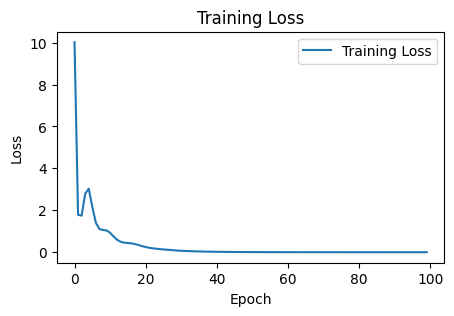

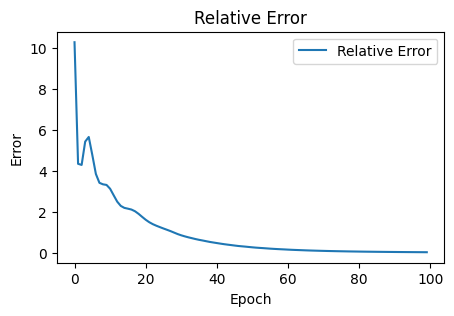

tensor(0.0258, device='cuda:0')


In [11]:
# Assume MTM is a sparse tensor of shape (d2, d2)
MTM = MTM.coalesce()
indices = MTM.indices()  # Shape: (2, nnz)
values = MTM.values()    # Shape: (nnz,)

d2 = MTM.shape[0]
r = 10  # Desired rank
device = MTM.device

# Initialize U and V
U = torch.randn(d2, r, device=device, requires_grad=True)
V = torch.randn(d2, r, device=device, requires_grad=True)

optimizer = optim.Adam([U, V], lr=1)
epochs = 100
tol = 1e-5
train_losses = []
err_estimates = []

loop = tqdm(range(epochs))
for epoch in loop:
    optimizer.zero_grad()
    
    # Compute predictions at non-zero positions
    row_indices = indices[0]  # Shape: (nnz,)
    col_indices = indices[1]  # Shape: (nnz,)
    preds = torch.sum(U[row_indices] * V[col_indices], dim=1)  # Shape: (nnz,)
    
    # Compute loss
    diff = preds - values
    loss = torch.mean(diff ** 2)
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Compute relative error using only non-zero elements
    err_norm = torch.norm(diff)
    MTM_norm = torch.norm(values)
    relative_err = err_norm / MTM_norm
    err_estimates.append(relative_err.item())
    
    loop.set_description(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}, Rel Err: {relative_err:.6f}")
    
    # Check convergence
    if epoch > 0 and abs(err_estimates[-1] - err_estimates[-2]) < tol:
        print("Convergence achieved.")
        break

# After training, compute X_pred in sparse form
with torch.no_grad():
    X_pred_values = torch.sum(U[row_indices] * V[col_indices], dim=1)
    X_pred = torch.sparse_coo_tensor(indices, X_pred_values, size=MTM.shape, device=MTM.device).coalesce()

X = X_pred

# X_pred is now a sparse tensor
print(f"Number of non-zero elements in X_pred: {X_pred._nnz()}")
# Plotting training loss
plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

# Plotting relative error
plt.figure(figsize=(5, 3))
plt.plot(err_estimates, label='Relative Error')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.title('Relative Error')
plt.legend()
plt.show()

err = MTM.to_dense() - X.to_dense()
relative_err = torch.norm(err, 'fro') / torch.norm(MTM.to_dense(), 'fro')
print(relative_err)

$U\times V = M$ 

In order to solve $AX=B$, we have 

$
X=U^T \in r\times d_1, \\
A=V^T \in d_2\times r, \\
B=M^T \in d_2\times d_2
$

Then $V^TU^T=M^T$


In [12]:
error_list = []
missing_num = 0
total_num = 0
skip = 0
use_reg = False
U_list = []
estimation_goal = X

# Ensure 'X' is converted to dense for SVD
if estimation_goal.is_sparse:
    estimation_goal_dense = estimation_goal.to_dense()
else:
    estimation_goal_dense = estimation_goal

# Obtain 'V' from the power method
#_, _, V = power_svd(estimation_goal_dense, k=r)  # V: (d2, r)
estimation_goal_scipy = torch_sparse_to_scipy(estimation_goal)
_, _, V = scipy.sparse.linalg.svds(estimation_goal_scipy, k=r)
V = torch.tensor(V).to(device)

# Ensure 'V' is of shape (r, d2)
#V = V.t()  # Now V: (r, d2)
print(V.shape)

M = M.coalesce()
masks = masks.coalesce()

device = M.device
d2 = M.shape[1]
#_, _, V = power_svd(X.to_dense(), k=r)
for i in tqdm(range(M.shape[0])):
    # Extract the i-th row from M and masks
    M_row_sparse = M[i].coalesce()
    mask_row_sparse = masks[i].coalesce()

    # Convert the sparse row to dense
    #M_row_dense = torch.zeros(d2, device=device)
    M_row_dense = M_row_sparse.to_dense()
    mask_row_dense = mask_row_sparse.to_dense()
    """
    if M_row_sparse._nnz() > 0:
        M_row_dense[M_row_sparse.indices()[1]] = M_row_sparse.values()

    mask_row_dense = torch.zeros(d2, dtype=torch.bool, device=device)
    if mask_row_sparse._nnz() > 0:
        mask_row_dense[mask_row_sparse.indices()[1]] = mask_row_sparse.values().bool()
    """

    # Get non-zero indices in M_row_dense
    non_zero_indices = M_row_dense.nonzero(as_tuple=True)[0]
    M_row_dense = M_row_dense.unsqueeze(0)

    if non_zero_indices.numel() == 0:
        skip += 1
        continue

    # Separate observed and missing indices
    observed_mask = mask_row_dense[non_zero_indices].bool()
    #print(observed_mask)
    observed_idx = non_zero_indices[observed_mask]
    missing_idx = non_zero_indices[~observed_mask]

    if observed_idx.numel() == 0 or missing_idx.numel() == 0:
        skip += 1
        continue

    missing_num += missing_idx.numel()
    total_num += observed_idx.numel() + missing_idx.numel()

    # Prepare 'observed_A' and 'observed_B'
    observed_A = V[:, observed_idx].t().clone()  # Shape: (num_observed, r)
    observed_B = M_row_dense[:, observed_idx].t().clone()  # Shape: (num_observed, 1)
    missing_A = V[:, missing_idx].t()
    missing_B = M_row_dense[:, missing_idx].t()

    # Solve for user factor 'u' using regression
    if use_reg:
        # Ridge regression
        lambda_reg = 0.001
        I = torch.eye(r, device=device) * lambda_reg
        A_t_A = observed_A.t() @ observed_A + I
        A_t_B = observed_A.t() @ observed_B
        try:
            u = torch.linalg.solve(A_t_A, A_t_B)  # Shape: (r, 1)
        except RuntimeError as e:
            print(f"LinAlgError for user {i}: {e}")
            skip += 1
            continue
    else:
        # Linear regression
        u = torch.linalg.lstsq(observed_A, observed_B).solution  # Shape: (r, 1)

    # Check for NaN values
    if torch.any(torch.isnan(u)):
        print(f"NAN detected in user {i}!")
        skip += 1
        continue

    # Store the user factor
    U_list.append(u.t())  # Shape: (1, r)


    # Compute the error on missing entries
    predictions = missing_A @ u  # Shape: (num_missing, 1)
    errors = predictions - missing_B  # Shape: (num_missing, 1)
    error_list.append(torch.sum(errors ** 2).item())

    # Release variables to free memory
    del M_row_sparse, mask_row_sparse, M_row_dense, mask_row_dense, observed_A, observed_B, missing_A, missing_B, predictions, errors, u

# Compute the root mean squared error over missing entries
rmse_missing = np.sqrt(np.sum(error_list) / missing_num)
print(f"Skipped users due to lack of data: {skip}")
print(f"Total missing entries evaluated: {missing_num}")
print(f"RMSE on missing entries: {rmse_missing:.6f}")


torch.Size([10, 10000])


100%|██████████| 10/10 [00:00<00:00, 98.33it/s]

Skipped users due to lack of data: 6
Total missing entries evaluated: 3393
RMSE on missing entries: 0.003392


In [22]:
"""
import torch.nn.utils.rnn as rnn_utils
error_list = []
missing_num = 0
total_num = 0
skip = 0
result_list_missing = []
result_list_total = []
use_reg = False
U = []

#estimation_goal = torch.rand(X.shape).to(device)
estimation_goal = X

observed_A_list = []
observed_B_list = []

#_, S, V = top_r_svd(estimation_goal, r)
_, _, V = power_svd(estimation_goal, k=r)
for i in tqdm(range(M.shape[0])):
    
    # M_row: 1*d2
    # V: r*d2
    # user_vector: 1*r
    

    # make sure there is non-zero value in original matrix
    M_row = M[i]
    non_zero_indices = M_row.nonzero(as_tuple=True)[0]

    #non_zero_indices = torch.tensor(range(M_row.shape[0]))

    # select non-zero & masked elements as training data, non-zero & non-masked elements as testing data
    observed_idx = []
    missing_idx = []
    for non_zero_idx in non_zero_indices:
        if masks[i][non_zero_idx]:
            observed_idx.append(non_zero_idx.item())
        else:
            missing_idx.append(non_zero_idx.item())

    M_row = M_row.unsqueeze(0)
    n = non_zero_indices.shape[0]

    #if len(observed_idx)==0 or len(missing_idx) == 0:
    #    skip +=1
    #    continue
    missing_num += len(missing_idx)
    total_num += len(missing_idx) + len(observed_idx)

    observed_idx = torch.tensor(observed_idx)
    missing_idx = torch.tensor(missing_idx)

    # formula AX=B
    observed_A = V[:, observed_idx].t()
    observed_B = M_row[:, observed_idx].t()
    missing_A = V[:, missing_idx].t()
    missing_B = M_row[:, missing_idx].t()

    observed_A_list.append(observed_A)
    observed_B_list.append(observed_B)

padded_A = rnn_utils.pad_sequence(observed_A_list, batch_first=True, padding_value=0)
padded_B = rnn_utils.pad_sequence(observed_B_list, batch_first=True, padding_value=0)

U_t = torch.linalg.lstsq(padded_A, padded_B).solution
U = U_t.squeeze(-1)
M_ret = U @ V
err = torch.norm(M-M_ret, p=2) / missing_num
print(err)
"""

'\nimport torch.nn.utils.rnn as rnn_utils\nerror_list = []\nmissing_num = 0\ntotal_num = 0\nskip = 0\nresult_list_missing = []\nresult_list_total = []\nuse_reg = False\nU = []\n\n#estimation_goal = torch.rand(X.shape).to(device)\nestimation_goal = X\n\nobserved_A_list = []\nobserved_B_list = []\n\n#_, S, V = top_r_svd(estimation_goal, r)\n_, _, V = power_svd(estimation_goal, k=r)\nfor i in tqdm(range(M.shape[0])):\n    \n    # M_row: 1*d2\n    # V: r*d2\n    # user_vector: 1*r\n    \n\n    # make sure there is non-zero value in original matrix\n    M_row = M[i]\n    non_zero_indices = M_row.nonzero(as_tuple=True)[0]\n\n    #non_zero_indices = torch.tensor(range(M_row.shape[0]))\n\n    # select non-zero & masked elements as training data, non-zero & non-masked elements as testing data\n    observed_idx = []\n    missing_idx = []\n    for non_zero_idx in non_zero_indices:\n        if masks[i][non_zero_idx]:\n            observed_idx.append(non_zero_idx.item())\n        else:\n           